In [1]:
import pandas as pd


In [2]:
#Read the Netflix titles fom CSV file.
df = pd.read_csv("C:\\Users\\ardhr\\Github\\netflix_titles.csv")

In [3]:
#Check first few rows
df.head()



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Number of rows and columns (size of dataset)
df.shape


(8807, 12)

In [5]:
# CheCk the column names 
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
# chcek if there is any null values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
# Check for categorical missing values
# Text based values are replaced with 'Unknown'
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')

In [8]:
#Value based data is replaced with mode
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
valid_ratings = [
    'TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13',
    'PG', 'G', 'NR', 'UR', 'TV-Y7', 'TV-Y',
    'TV-G', 'TV-Y7-FV', 'NC-17'
]
df = df[df['rating'].isin(valid_ratings)]

In [9]:
# Date is converted to prper date format
# Invalid values are converted to NaT instead of crashing
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [10]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

## What does Netflix focus on?

In [11]:

# Check for the 'type' and how many opf each exixt (value-counts())

df['type'].value_counts()

Movie      6128
TV Show    2676
Name: type, dtype: int64

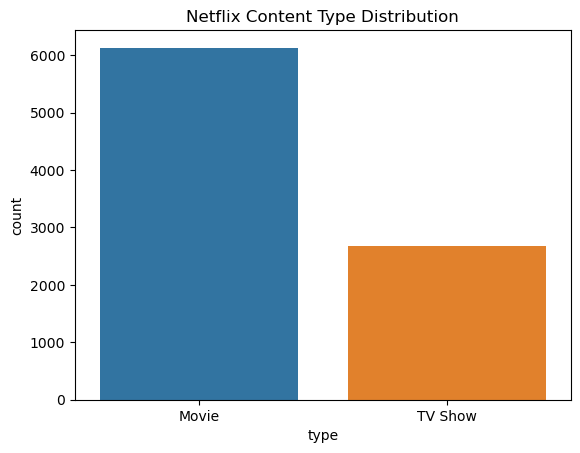

In [12]:
#Visulisation seaboarn for graphs and matlplotlib.pyplot for core plotting sytem
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title("Netflix Content Type Distribution")
plt.show()

### Netflix Content growth Over Time

In [13]:

#Extracting yearly contents.
#values_counts() used for counting no of titles per year
#sort_index() arranges years in order to show the trend
yearly_content = df['year_added'].value_counts().sort_index()

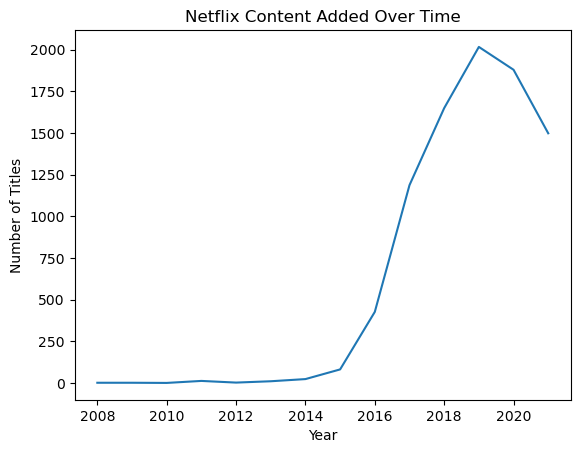

In [14]:
#Plotting the trend
yearly_content.plot(kind='line')

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [15]:

type_trend = df.pivot_table(index='year_added', columns='type', aggfunc='size')
#Handling missing values
type_trend = type_trend.fillna(0)
type_trend.head(14)


type,Movie,TV Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,0.0
2010.0,1.0,0.0
2011.0,13.0,0.0
2012.0,3.0,0.0
2013.0,6.0,5.0
2014.0,19.0,5.0
2015.0,56.0,26.0
2016.0,251.0,176.0


### Did Netflix grow movies and TV shows equally over time, or did one dominate?

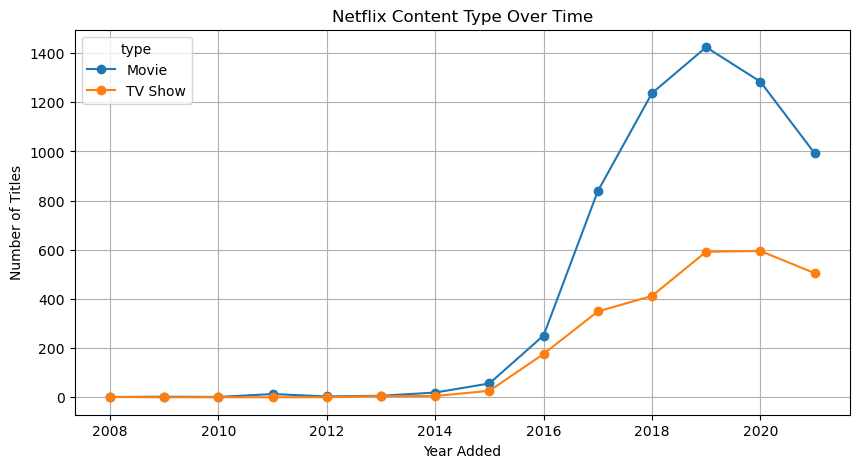

In [16]:
#Vizulisation on content type ove time
type_trend.plot(kind='line',figsize=(10,5), marker='o')

plt.title('Netflix Content Type Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

### Which countries dominate Netflix content creation?


In [17]:
#Remove countries wghich as unknown and spliting multiple countries
df_clean = df[df['country'] != 'Unknown']
countries = df_clean['country'].str.split(',')

In [18]:
# Extracting names of countries from the list where mutplie countries were shown
# Removing unneccssary space and counting the countries.

countries_expanded = countries.explode()
countries_expanded = countries_expanded.str.strip()
top_countries = countries_expanded.value_counts().head(10)

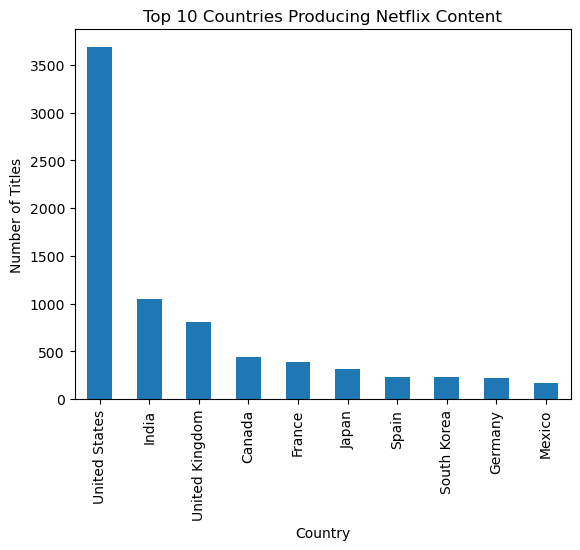

In [19]:
#Vizulisation of top countries

top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

### What types of content Netflix produces most (Drama, Comedy, Action, etc.)


In [20]:
genres = df ['listed_in'].str.split(',')
genres.head()
genres_expanded = genres.explode()
genres_expanded = genres_expanded.str.strip()
top_genres= genres_expanded.value_counts().head(10)

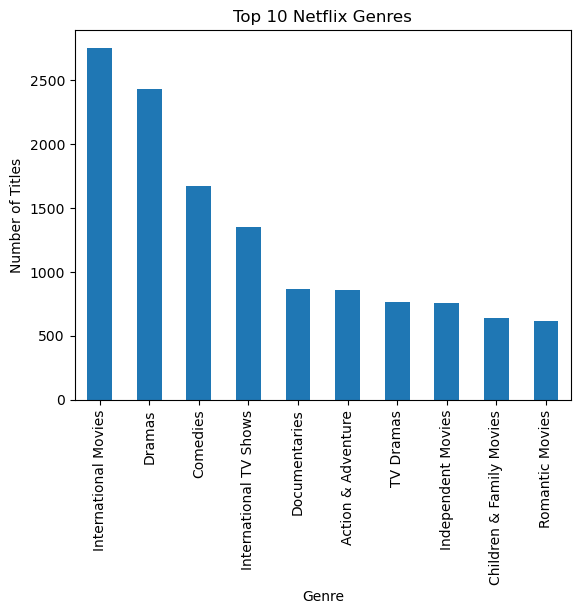

In [21]:
#Vizualization on the top 10 genres on netflix
top_genres.plot(kind='bar')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()

### Which content had more rating?

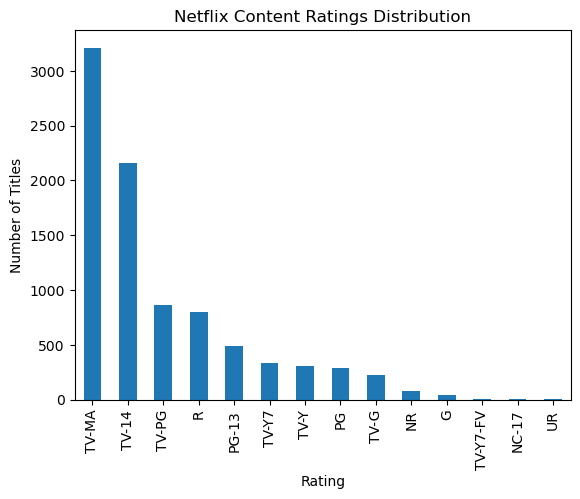

In [22]:

df['rating'].value_counts().plot(kind='bar')

plt.title("Netflix Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()

## Rating meaning 

In [23]:
rating_meaning = {
    'TV-MA': 'Mature Audience (18+)',
    'TV-14': 'Teens 14+',
    'TV-PG': 'Parental Guidance',
    'TV-Y': 'All Children',
    'TV-Y7': '7+ Children',
    'TV-Y7-FV': 'Fantasy Violence (Kids)',
    'TV-G': 'General Audience',
    'PG': 'Parental Guidance (Movies)',
    'PG-13': '13+ Movies',
    'R': 'Restricted (17+)',
    'NC-17': 'Adults Only (18+)',
    'NR': 'Not Rated',
    'UR': 'Unrated'
}



rating_table = pd.DataFrame(list(rating_meaning.items()),
                            columns=['Rating', 'Meaning'])

rating_table

,Rating,Meaning
0,TV-MA,Mature Audience (18+)
1,TV-14,Teens 14+
2,TV-PG,Parental Guidance
3,TV-Y,All Children
4,TV-Y7,7+ Children
5,TV-Y7-FV,Fantasy Violence (Kids)
6,TV-G,General Audience
7,PG,Parental Guidance (Movies)
8,PG-13,13+ Movies
9,R,Restricted (17+)


# Dashboard

In [24]:
#Creat a dashboard 
rating_counts = df['rating'].value_counts()
type_counts = df['type'].value_counts()
yearly_content = df['year_added'].value_counts().sort_index()
top_countries = countries_expanded.value_counts().head(10)
top_genres = genres_expanded.value_counts().head(10)

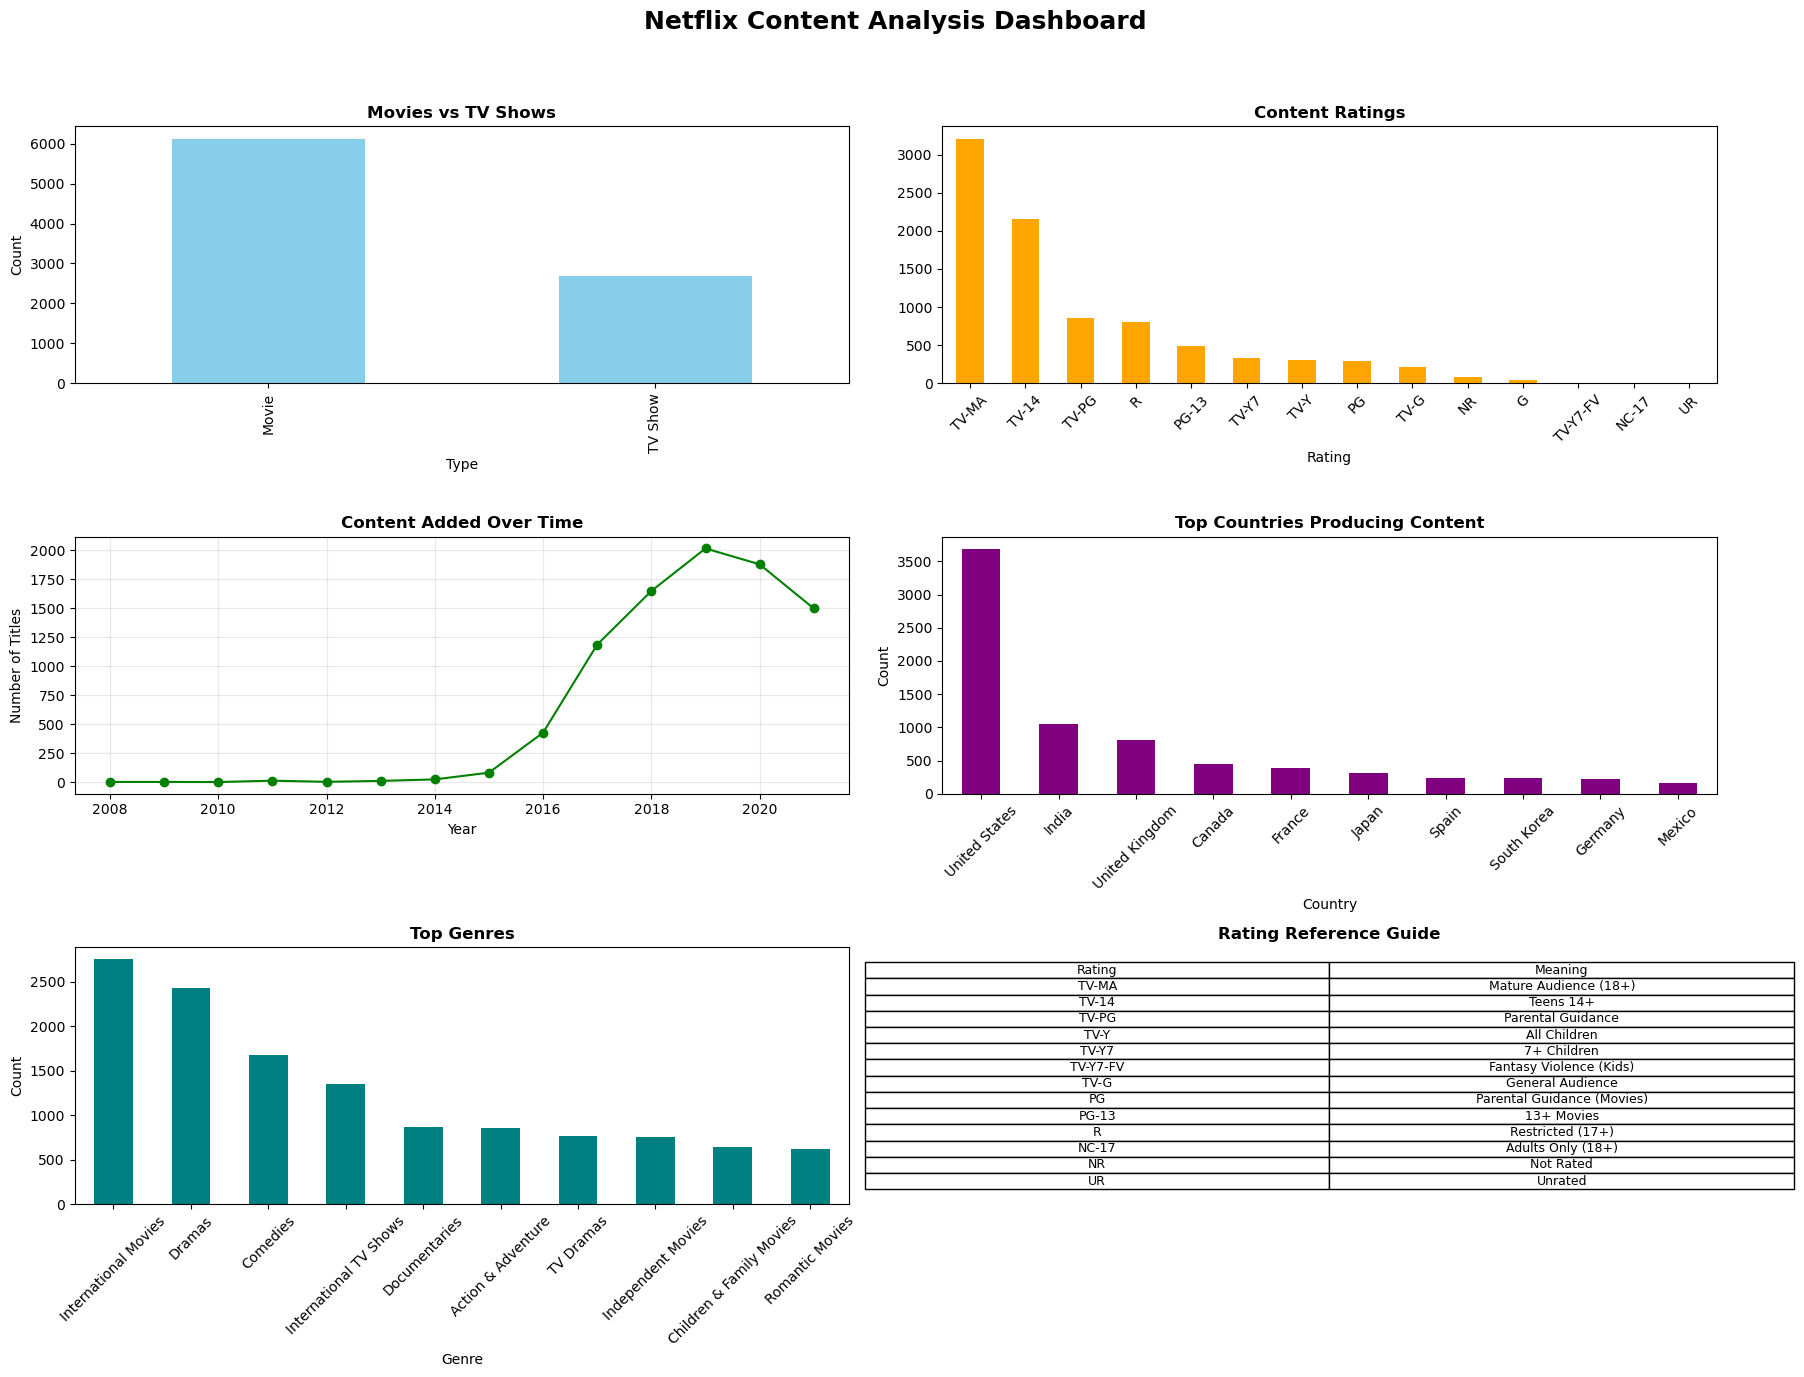

In [25]:

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Overall title (important for portfolio)
fig.suptitle("Netflix Content Analysis Dashboard", fontsize=18, fontweight='bold')


# ---------------- 1. Movies vs TV Shows ----------------
type_counts.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Movies vs TV Shows', fontweight='bold')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Count')


# ---------------- 2. Ratings ----------------
rating_counts.plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Content Ratings', fontweight='bold')
axes[0,1].set_xlabel('Rating')
axes[0,1].tick_params(axis='x', rotation=45)


# ---------------- 3. Content Growth Over Time ----------------
yearly_content.plot(kind='line', marker='o', ax=axes[1,0], color='green')
axes[1,0].set_title('Content Added Over Time', fontweight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Number of Titles')
axes[1,0].grid(alpha=0.3)


# ---------------- 4. Top Countries ----------------
top_countries.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Top Countries Producing Content', fontweight='bold')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)


# ---------------- 5. Top Genres ----------------
top_genres.plot(kind='bar', ax=axes[2,0], color='teal')
axes[2,0].set_title('Top Genres', fontweight='bold')
axes[2,0].set_xlabel('Genre')
axes[2,0].set_ylabel('Count')
axes[2,0].tick_params(axis='x', rotation=45)


# ---------------- 6. Rating Meaning Table ----------------
axes[2,1].axis('off')

table = axes[2,1].table(
    cellText=rating_table.values,
    colLabels=rating_table.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.2)

axes[2,1].set_title('Rating Reference Guide', fontweight='bold')


# Adjust layout for clean spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()